### 1. Import Libraries

In [1]:
import pandas as pd

from statsmodels.tsa.seasonal import seasonal_decompose

### 2. Load and Prepare Data

In [2]:
df = pd.read_csv(
    '../data/raw/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

In [3]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

In [4]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [5]:
df = df.apply(pd.to_numeric)

df.interpolate(method='time', inplace=True)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0


In [6]:
energy_hourly = df['Global_active_power'].resample('h').mean()

energy_hourly.interpolate(method='time', inplace=True)

datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
                         ...   
2010-11-26 17:00:00    1.725900
2010-11-26 18:00:00    1.573467
2010-11-26 19:00:00    1.659333
2010-11-26 20:00:00    1.163700
2010-11-26 21:00:00    0.934667
Freq: h, Name: Global_active_power, Length: 34589, dtype: float64

### 3. Time Series Decomposition (Daily Seasonality)

Time series decomposition is used to separate the data into trend, seasonal, and residual components. This helps in understanding underlying patterns and preparing for forecasting models.

In [9]:
decomposition = seasonal_decompose(
    energy_hourly, 
    model='additive', 
    period=24
)

### 4. Decomposition Visualization

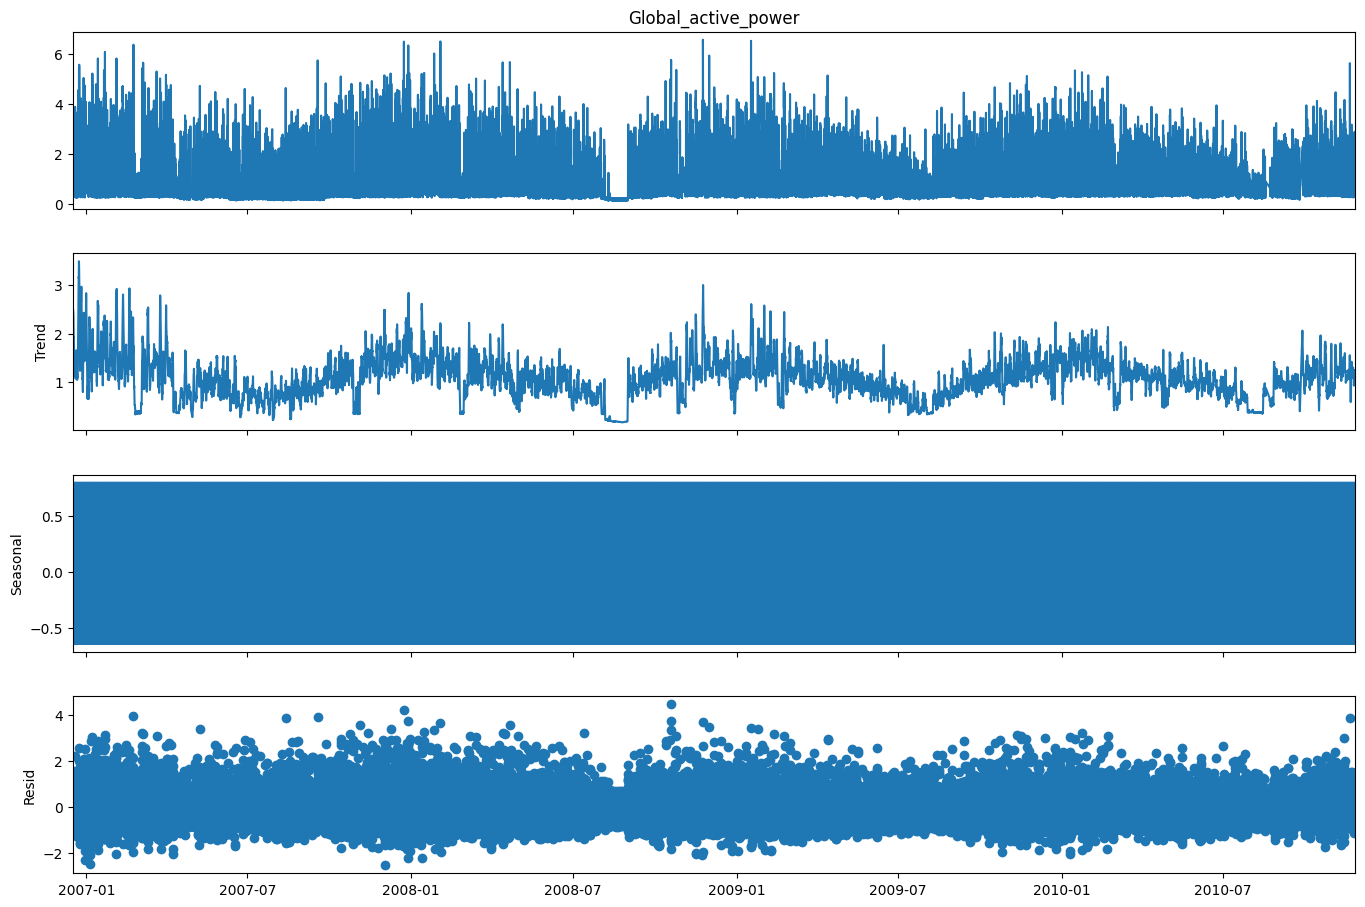

In [10]:

fig = decomposition.plot()
fig.set_size_inches(15, 10)

### Decomposition Analysis

- **Trend Component:** Shows the overall direction of energy consumption over time.
- **Seasonal Component:** Reveals repeating daily patterns, confirming strong daily seasonality.
- **Residual Component:** Represents irregular fluctuations and noise not explained by trend or seasonality.

The presence of clear seasonal patterns supports the use of models like Prophet, which can capture multiple seasonalities effectively.

### 5. Weekly Seasonality Decomposition

A weekly decomposition was also performed to capture longer seasonal cycles across days of the week.

In [13]:
decomposition_week = seasonal_decompose(
    energy_hourly, 
    model='additive', 
    period=168
) # 24 hours × 7 days = 168

### 6. Interpretation of Components (Trend, Seasonality, Residual)

In [ ]:
fig = decomposition_week.plot()
fig.set_size_inches(15, 10)

### 7. Key Insights

- The time series exhibits strong daily seasonality.
- Weekly patterns are also present, though less pronounced.
- The residual component appears mostly random, indicating that the trend and seasonality capture most of the structure in the data.